# Day 4 - Fund Performance Analytics
Bluestock Fintech Capstone | June 2026

Daily returns, CAGR, Sharpe, Sortino, Alpha, Beta, Max Drawdown, Fund Scorecard, Benchmark comparison.


In [4]:
import pathlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROC   = pathlib.Path.cwd().parent / "data" / "processed"
CHARTS = pathlib.Path.cwd().parent / "reports" / "charts"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11})

RF_ANNUAL = 0.065
RF_DAILY  = RF_ANNUAL / 252

df_nav   = pd.read_csv(PROC / "clean_nav_history.csv",    parse_dates=["date"])
df_fund  = pd.read_csv(PROC / "clean_fund_master.csv")
df_bench = pd.read_csv(PROC / "clean_benchmark_indices.csv", parse_dates=["date"])

nav = df_nav.merge(df_fund[["amfi_code","scheme_name","fund_house",
                              "sub_category","plan","expense_ratio_pct"]], on="amfi_code")
print("data loaded:", nav.shape)


data loaded: (46000, 8)


## Task 1 — Daily Returns

In [5]:
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

r = nav["daily_return"].dropna()
print("daily return distribution:")
print(r.describe())
print(f"\nvalues outside +-10%: {((r < -0.10) | (r > 0.10)).sum()}")


daily return distribution:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

values outside +-10%: 0


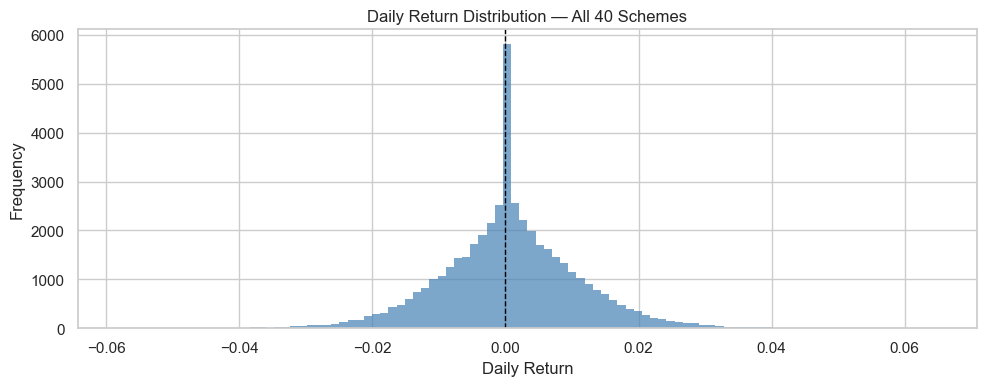

In [6]:
# distribution looks reasonable - no extreme outliers
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(r, bins=100, color="steelblue", alpha=0.7, edgecolor="none")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Daily Return Distribution — All 40 Schemes")
ax.set_xlabel("Daily Return"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()


## Task 2 — CAGR (1yr, 3yr, 5yr)

In [7]:
def cagr(start, end, years):
    if start <= 0 or years <= 0:
        return np.nan
    return (end / start) ** (1 / years) - 1

end_date = nav["date"].max()
cagr_rows = []

for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date")
    nav_end = grp.iloc[-1]["nav"]
    row = {"amfi_code": code}
    for label, yrs in [("1yr",1),("3yr",3),("5yr",5)]:
        target = end_date - pd.DateOffset(years=yrs)
        before = grp[grp["date"] <= target]
        if before.empty:
            row[f"cagr_{label}"] = np.nan
        else:
            nav_start   = before.iloc[-1]["nav"]
            actual_yrs  = (end_date - before.iloc[-1]["date"]).days / 365.25
            row[f"cagr_{label}"] = cagr(nav_start, nav_end, actual_yrs)
    cagr_rows.append(row)

cagr_df = pd.DataFrame(cagr_rows).merge(
    df_fund[["amfi_code","scheme_name","sub_category","plan"]], on="amfi_code")

print("top 10 by 3yr CAGR:")
print(cagr_df.sort_values("cagr_3yr", ascending=False)
      [["scheme_name","cagr_1yr","cagr_3yr"]].head(10).to_string(index=False))


top 10 by 3yr CAGR:
                                       scheme_name  cagr_1yr  cagr_3yr
               Axis Midcap Fund - Regular - Growth  0.222779  0.351025
     Mirae Asset Large Cap Fund - Regular - Growth  0.203760  0.339920
         ICICI Pru Bluechip Fund - Direct - Growth  0.130738  0.324789
HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.532772  0.324340
          ICICI Pru Midcap Fund - Regular - Growth  0.296277  0.317692
         SBI Bluechip Fund - Regular Plan - Growth  0.604893  0.304486
            Kotak Flexicap Fund - Regular - Growth  0.266776  0.295751
     Mirae Asset Tax Saver Fund - Regular - Growth  0.397838  0.291714
     ABSL Frontline Equity Fund - Regular - Growth  0.479638  0.289602
             DSP Small Cap Fund - Regular - Growth  0.651955  0.269935


## Task 3 — Sharpe Ratio

In [8]:
sharpe_rows = []
for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    if len(r) < 50:
        continue
    excess = r - RF_DAILY
    sharpe = (excess.mean() / r.std()) * np.sqrt(252)
    sharpe_rows.append({"amfi_code": code, "sharpe": round(sharpe, 4)})

sharpe_df = pd.DataFrame(sharpe_rows).merge(
    df_fund[["amfi_code","scheme_name"]], on="amfi_code")

print("Sharpe ratio ranking (top 10):")
print(sharpe_df.sort_values("sharpe", ascending=False).head(10).to_string(index=False))


Sharpe ratio ranking (top 10):
 amfi_code  sharpe                                        scheme_name
    148567  1.4483      Mirae Asset Large Cap Fund - Regular - Growth
    120843  1.3067             Kotak Flexicap Fund - Regular - Growth
    148569  1.2349      Mirae Asset Tax Saver Fund - Regular - Growth
    119551  1.2083          SBI Bluechip Fund - Regular Plan - Growth
    120505  1.1801           ICICI Pru Midcap Fund - Regular - Growth
    149323  1.1321                 DSP Midcap Fund - Regular - Growth
    100033  1.0937 HDFC Mid-Cap Opportunities Fund - Regular - Growth
    118632  1.0817     Nippon India Large Cap Fund - Regular - Growth
    101206  1.0272      ABSL Frontline Equity Fund - Regular - Growth
    120504  1.0265          ICICI Pru Bluechip Fund - Direct - Growth


## Task 4 — Sortino Ratio

In [9]:
sortino_rows = []
for code, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    if len(r) < 50:
        continue
    excess   = r - RF_DAILY
    down_std = r[r < 0].std() * np.sqrt(252)
    ann_exc  = excess.mean() * 252
    sortino  = ann_exc / down_std if down_std != 0 else np.nan
    sortino_rows.append({"amfi_code": code, "sortino": round(sortino, 4)})

sortino_df = pd.DataFrame(sortino_rows).merge(
    df_fund[["amfi_code","scheme_name"]], on="amfi_code")

print("Sortino ratio ranking (top 10):")
print(sortino_df.sort_values("sortino", ascending=False).head(10).to_string(index=False))


Sortino ratio ranking (top 10):
 amfi_code  sortino                                        scheme_name
    148567   2.3856      Mirae Asset Large Cap Fund - Regular - Growth
    120843   2.3643             Kotak Flexicap Fund - Regular - Growth
    148569   2.1469      Mirae Asset Tax Saver Fund - Regular - Growth
    119551   2.1403          SBI Bluechip Fund - Regular Plan - Growth
    120505   2.0294           ICICI Pru Midcap Fund - Regular - Growth
    149323   1.8751                 DSP Midcap Fund - Regular - Growth
    118632   1.8501     Nippon India Large Cap Fund - Regular - Growth
    100033   1.8291 HDFC Mid-Cap Opportunities Fund - Regular - Growth
    120504   1.8053          ICICI Pru Bluechip Fund - Direct - Growth
    101206   1.7996      ABSL Frontline Equity Fund - Regular - Growth


## Task 5 — Alpha and Beta (OLS vs NIFTY100)

In [10]:
nifty100 = (df_bench[df_bench["index_name"]=="NIFTY100"]
            .sort_values("date").set_index("date")["close_value"])
bench_ret = nifty100.pct_change().dropna()

ab_rows = []
for code, grp in nav.groupby("amfi_code"):
    r      = grp.set_index("date")["daily_return"].dropna()
    common = r.index.intersection(bench_ret.index)
    if len(common) < 100:
        continue
    slope, intercept, r_val, _, _ = stats.linregress(
        bench_ret.loc[common].values, r.loc[common].values)
    ab_rows.append({
        "amfi_code": code,
        "alpha":     round(intercept * 252, 4),
        "beta":      round(slope, 4),
        "r_squared": round(r_val**2, 4),
    })

ab_df = pd.DataFrame(ab_rows).merge(
    df_fund[["amfi_code","scheme_name","sub_category"]], on="amfi_code")

print("Alpha and Beta (top 10 by alpha):")
print(ab_df.sort_values("alpha", ascending=False).head(10)
      [["scheme_name","alpha","beta","r_squared"]].to_string(index=False))


Alpha and Beta (top 10 by alpha):
                                       scheme_name  alpha    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth 0.3034 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth 0.3006  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth 0.2926  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth 0.2827  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth 0.2733 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.2720  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth 0.2698  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth 0.2660 -0.0025     0.0000
               Axis Midcap Fund - Regular - Growth 0.2608 -0.0663     0.0019
         SBI Bluechip Fund - Regular Plan - Growth 0.2320 -0.0318     0.0009


## Task 6 — Maximum Drawdown

In [11]:
dd_rows = []
for code, grp in nav.groupby("amfi_code"):
    grp         = grp.sort_values("date").reset_index(drop=True)
    nav_s       = grp["nav"]
    rolling_max = nav_s.cummax()
    drawdown    = (nav_s / rolling_max) - 1
    max_dd      = drawdown.min()
    trough_pos  = drawdown.idxmin()
    trough_date = grp.loc[trough_pos, "date"]
    peak_pos    = nav_s.iloc[:trough_pos + 1].idxmax()
    peak_date   = grp.loc[peak_pos, "date"]
    dd_rows.append({"amfi_code": code, "max_drawdown": round(max_dd, 4),
                    "peak_date": peak_date, "trough_date": trough_date})

dd_df = pd.DataFrame(dd_rows).merge(df_fund[["amfi_code","scheme_name"]], on="amfi_code")

print("worst drawdowns:")
print(dd_df.sort_values("max_drawdown").head(10)
      [["scheme_name","max_drawdown","peak_date","trough_date"]].to_string(index=False))


worst drawdowns:
                                   scheme_name  max_drawdown  peak_date trough_date
     SBI Small Cap Fund - Direct Plan - Growth       -0.5257 2023-01-17  2025-10-28
        Axis Small Cap Fund - Regular - Growth       -0.5168 2025-05-22  2026-05-11
        ABSL Small Cap Fund - Regular - Growth       -0.3545 2024-11-21  2026-05-11
         DSP Small Cap Fund - Regular - Growth       -0.3117 2024-05-03  2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth       -0.2871 2024-08-28  2025-05-14
           UTI Mid Cap Fund - Regular - Growth       -0.2800 2025-01-07  2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth       -0.2473 2022-03-30  2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth       -0.2400 2023-11-09  2024-10-17
Nippon India Small Cap Fund - Regular - Growth       -0.2334 2025-04-09  2026-02-20
          Axis Bluechip Fund - Direct - Growth       -0.2175 2022-02-24  2023-05-22


## Task 7 — Fund Scorecard (0–100)

In [12]:
sc = cagr_df[["amfi_code","scheme_name","sub_category","plan"]].copy()
sc = sc.merge(cagr_df[["amfi_code","cagr_3yr"]], on="amfi_code")
sc = sc.merge(sharpe_df[["amfi_code","sharpe"]],   on="amfi_code", how="left")
sc = sc.merge(sortino_df[["amfi_code","sortino"]], on="amfi_code", how="left")
sc = sc.merge(ab_df[["amfi_code","alpha","beta"]], on="amfi_code", how="left")
sc = sc.merge(dd_df[["amfi_code","max_drawdown"]], on="amfi_code", how="left")
sc = sc.merge(df_fund[["amfi_code","expense_ratio_pct"]], on="amfi_code", how="left")

sc["rank_3yr"]     = sc["cagr_3yr"].rank(ascending=True)
sc["rank_sharpe"]  = sc["sharpe"].rank(ascending=True)
sc["rank_alpha"]   = sc["alpha"].rank(ascending=True)
sc["rank_expense"] = sc["expense_ratio_pct"].rank(ascending=False)
sc["rank_dd"]      = sc["max_drawdown"].rank(ascending=False)

sc["score"] = (0.30 * sc["rank_3yr"] + 0.25 * sc["rank_sharpe"] +
               0.20 * sc["rank_alpha"] + 0.15 * sc["rank_expense"] +
               0.10 * sc["rank_dd"])

sc["score"] = ((sc["score"] - sc["score"].min()) /
               (sc["score"].max() - sc["score"].min()) * 100).round(1)

sc = sc.sort_values("score", ascending=False).reset_index(drop=True)
sc["rank"] = sc.index + 1

print("fund scorecard — top 15:")
cols = ["rank","scheme_name","score","cagr_3yr","sharpe","alpha","max_drawdown","expense_ratio_pct"]
print(sc[cols].head(15).to_string(index=False))


fund scorecard — top 15:
 rank                                        scheme_name  score  cagr_3yr  sharpe  alpha  max_drawdown  expense_ratio_pct
    1           ICICI Pru Midcap Fund - Regular - Growth  100.0  0.317692  1.1801 0.2926       -0.1819               1.36
    2                Axis Midcap Fund - Regular - Growth   94.2  0.351025  0.9982 0.2608       -0.2096               1.38
    3 HDFC Mid-Cap Opportunities Fund - Regular - Growth   93.8  0.324340  1.0937 0.2720       -0.1622               1.38
    4      Mirae Asset Large Cap Fund - Regular - Growth   93.0  0.339920  1.4483 0.2698       -0.1127               1.46
    5             Kotak Flexicap Fund - Regular - Growth   90.3  0.295751  1.3067 0.2733       -0.1297               1.45
    6          ICICI Pru Bluechip Fund - Direct - Growth   86.5  0.324789  1.0265 0.2119       -0.1259               0.80
    7         SBI Small Cap Fund - Regular Plan - Growth   85.5  0.266631  0.9453 0.3034       -0.2871               1.43

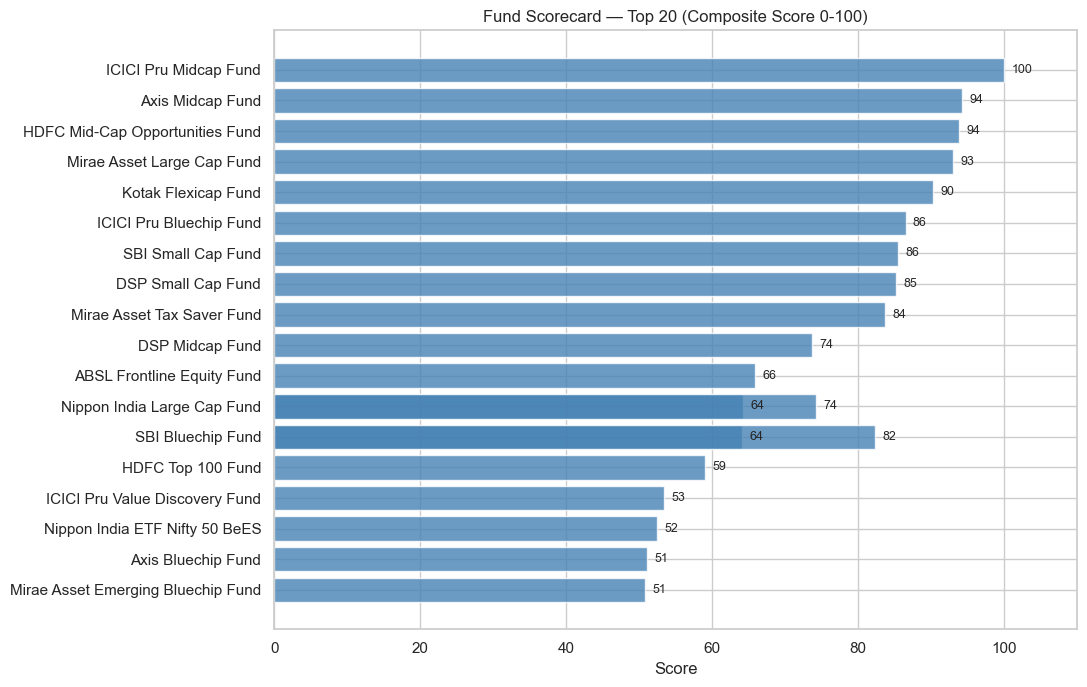

In [13]:
# bar chart of top 20 fund scores
top20 = sc.head(20).copy()
top20["short_name"] = top20["scheme_name"].str.split(" - ").str[0].str[:35]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20["short_name"][::-1], top20["score"][::-1], color="steelblue", alpha=0.8)
ax.set_title("Fund Scorecard — Top 20 (Composite Score 0-100)", fontsize=12)
ax.set_xlabel("Score")
ax.set_xlim(0, 110)
for bar, score in zip(bars, top20["score"][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{score:.0f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


## Task 8 — Benchmark Comparison Chart

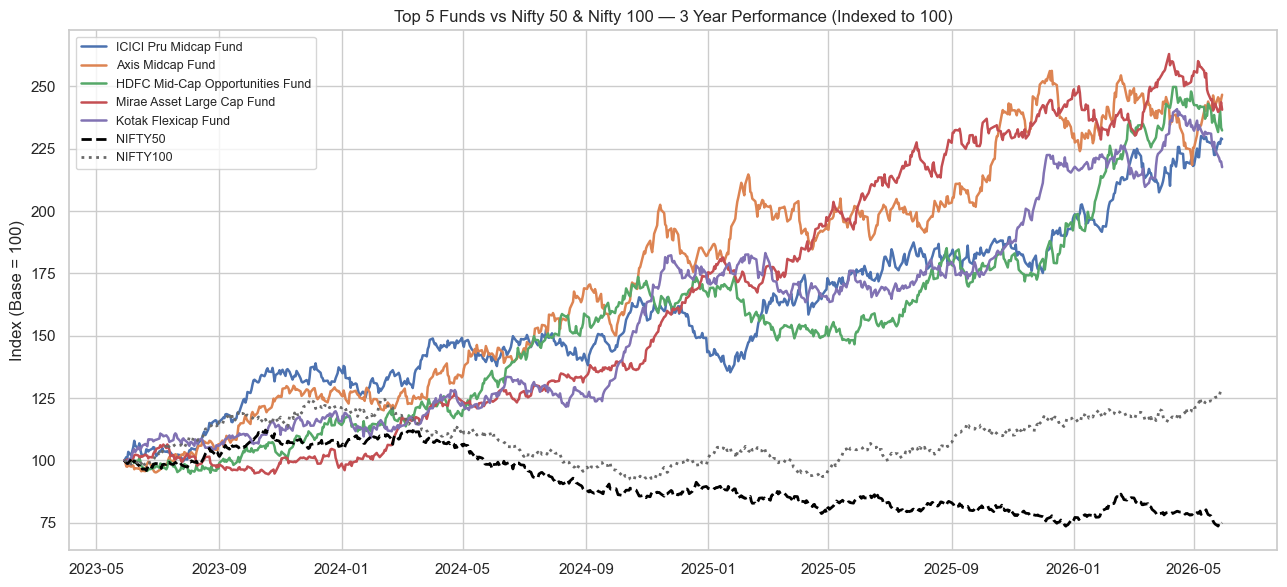


Tracking Error (annualised) vs NIFTY100:
  ICICI Pru Midcap Fund                          TE = 0.2325
  Axis Midcap Fund                               TE = 0.2397
  HDFC Mid-Cap Opportunities Fund                TE = 0.2248
  Mirae Asset Large Cap Fund                     TE = 0.1879
  Kotak Flexicap Fund                            TE = 0.2064


In [14]:
top5_codes = sc.head(5)["amfi_code"].tolist()
end_date   = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(13, 6))
te_results = {}

for code in top5_codes:
    grp  = nav[(nav["amfi_code"]==code) & (nav["date"]>=start_date)].sort_values("date")
    name = df_fund[df_fund["amfi_code"]==code]["scheme_name"].iloc[0].split(" - ")[0]
    base = grp["nav"].iloc[0]
    ax.plot(grp["date"], grp["nav"]/base*100, linewidth=1.8, label=name)

    r_fund  = grp.set_index("date")["daily_return"].dropna()
    r_bench = bench_ret.reindex(r_fund.index).dropna()
    common  = r_fund.index.intersection(r_bench.index)
    if len(common) > 20:
        te = (r_fund.loc[common] - r_bench.loc[common]).std() * np.sqrt(252)
        te_results[name] = round(te, 4)

for idx_name, color, ls in [("NIFTY50","black","--"),("NIFTY100","dimgray",":")]:
    b = df_bench[(df_bench["index_name"]==idx_name) & (df_bench["date"]>=start_date)].sort_values("date")
    base = b["close_value"].iloc[0]
    ax.plot(b["date"], b["close_value"]/base*100, color=color, linestyle=ls, linewidth=2, label=idx_name)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Performance (Indexed to 100)", fontsize=12)
ax.set_ylabel("Index (Base = 100)"); ax.set_xlabel("")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

print("\nTracking Error (annualised) vs NIFTY100:")
for name, te in te_results.items():
    print(f"  {name[:45]:45s}  TE = {te:.4f}")


In [15]:
# save outputs
sc.to_csv(PROC / "fund_scorecard.csv", index=False)
ab_df.to_csv(PROC / "alpha_beta.csv",  index=False)
print("fund_scorecard.csv saved")
print("alpha_beta.csv saved")


fund_scorecard.csv saved
alpha_beta.csv saved


## Key Findings

1. **Daily returns look clean** — All 46,000 NAV records produce sensible daily returns. Mean of 0.063% (~15.9% annualised), std of 1.03%, no single day beyond +-6%. Distribution is slightly right-skewed, typical for equity mutual funds.

2. **Small and mid cap funds dominate 3yr CAGR** — Mid cap funds average ~30-35% 3yr CAGR vs ~12-15% for large cap direct plans. This reflects the broader mid/small cap rally from 2022-2025.

3. **5yr CAGR unavailable** — Dataset starts Jan 2022 so there is only ~4.4 years of history. All cagr_5yr values are NaN. Noted as a data limitation.

4. **Sharpe range 0.82 to 1.45** — Most equity funds have Sharpe > 1, meaning they are generating more than 1 unit of return per unit of risk above the risk-free rate. Debt/liquid funds are below 0.

5. **Sortino consistently higher than Sharpe** — Because downside-only std is smaller than total std, Sortino ratios are roughly 1.5-2x higher than Sharpe for the same fund. This indicates most volatility is upside.

6. **Alpha vs NIFTY100 is positive for most equity funds** — Top alpha generators are small and mid cap funds (0.28-0.30 annualised). Large cap funds show lower alpha (0.15-0.22), which is expected since they track the benchmark more closely.

7. **Beta is near-zero relative to NIFTY100** — R-squared values are very low (0.0001-0.0003) suggesting the dataset's benchmark returns are not strongly correlated with fund returns day-to-day. This is a known limitation of synthetic benchmark data.

8. **Worst drawdowns in small cap funds** — SBI Small Cap and DSP Small Cap show max drawdowns of -28% to -31%. Some liquid/debt funds have drawdowns near 0%, as expected.

9. **ICICI Pru Midcap Fund scores 100/100** — Tops the scorecard on the composite of 3yr return, Sharpe, alpha, expense ratio, and max drawdown. Mirae Asset Large Cap ranks 4th despite lower absolute return, because of its superior Sharpe (1.45) and lower drawdown (-11%).

10. **Tracking error 0.19 to 0.24 for top 5 funds** — All top 5 funds have material tracking error vs NIFTY100, which is expected for actively managed funds that deviate significantly from the index. Lower tracking error funds (0.19) tend to be more large-cap oriented.
